In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

**Calendar: Data Cleaning & EDA**

In [4]:
calendar_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Calendar.csv')

In [5]:
calendar_df.head()

,Date
0,1/1/2015
1,1/2/2015
2,1/3/2015
3,1/4/2015
4,1/5/2015


In [6]:
calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    912 non-null    object
dtypes: object(1)
memory usage: 7.3+ KB


In [7]:
calendar_df.isnull().sum()

,0
Date,0


In [8]:
calendar_df.duplicated().sum()

np.int64(0)

In [10]:
calendar_df['Date'] = pd.to_datetime(calendar_df['Date'])

calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    912 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.3 KB


In [11]:
calendar_df['Year'] = calendar_df['Date'].dt.year
calendar_df['Month'] = calendar_df['Date'].dt.month
calendar_df['Month_Name'] = calendar_df['Date'].dt.month_name()
calendar_df['Day'] = calendar_df['Date'].dt.day
calendar_df['Day_Name'] = calendar_df['Date'].dt.day_name()

calendar_df.head()

,Date,Year,Month,Month_Name,Day,Day_Name
0,2015-01-01,2015,1,January,1,Thursday
1,2015-01-02,2015,1,January,2,Friday
2,2015-01-03,2015,1,January,3,Saturday
3,2015-01-04,2015,1,January,4,Sunday
4,2015-01-05,2015,1,January,5,Monday


In [13]:
calendar_df.to_csv(
    '/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Calendar_Cleaned.csv',
    index=False
)

**Customers: Data Cleaning & EDA**

In [15]:
customers_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Customers.csv', encoding='latin1')

In [16]:
customers_df.head()

,CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner
0,11000,MR.,JON,YANG,4/8/1966,M,M,jon24@adventure-works.com,"$90,000",2,Bachelors,Professional,Y
1,11001,MR.,EUGENE,HUANG,5/14/1965,S,M,eugene10@adventure-works.com,"$60,000",3,Bachelors,Professional,N
2,11002,MR.,RUBEN,TORRES,8/12/1965,M,M,ruben35@adventure-works.com,"$60,000",3,Bachelors,Professional,Y
3,11003,MS.,CHRISTY,ZHU,2/15/1968,S,F,christy12@adventure-works.com,"$70,000",0,Bachelors,Professional,N
4,11004,MRS.,ELIZABETH,JOHNSON,8/8/1968,S,F,elizabeth5@adventure-works.com,"$80,000",5,Bachelors,Professional,Y


In [20]:
customers_df.shape

(18148, 13)

In [17]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18148 entries, 0 to 18147
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerKey     18148 non-null  int64 
 1   Prefix          18018 non-null  object
 2   FirstName       18148 non-null  object
 3   LastName        18148 non-null  object
 4   BirthDate       18148 non-null  object
 5   MaritalStatus   18148 non-null  object
 6   Gender          18018 non-null  object
 7   EmailAddress    18148 non-null  object
 8   AnnualIncome    18148 non-null  object
 9   TotalChildren   18148 non-null  int64 
 10  EducationLevel  18148 non-null  object
 11  Occupation      18148 non-null  object
 12  HomeOwner       18148 non-null  object
dtypes: int64(2), object(11)
memory usage: 1.8+ MB


In [18]:
customers_df.isnull().sum()

,0
CustomerKey,0
Prefix,130
FirstName,0
LastName,0
BirthDate,0
MaritalStatus,0
Gender,130
EmailAddress,0
AnnualIncome,0
TotalChildren,0


In [19]:
customers_df.duplicated().sum()

np.int64(0)

In [22]:
customers_df['BirthDate'] = pd.to_datetime(customers_df['BirthDate'])

In [23]:
from datetime import datetime

current_year = datetime.now().year

customers_df['Age'] = current_year - customers_df['BirthDate'].dt.year

In [34]:
customers_df['AgeGroup'] = pd.cut(
    customers_df['Age'],
    bins=[0,25,35,45,55,100],
    labels=['18-25','26-35','36-45','46-55','55+']
)

In [25]:
customers_df['Gender'] = customers_df['Gender'].fillna('Unknown')

In [26]:
customers_df['Prefix'] = customers_df['Prefix'].fillna('Unknown')

In [27]:
customers_df['AnnualIncome'] = (
    customers_df['AnnualIncome']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [28]:
customers_df[['AnnualIncome']].head()

,AnnualIncome
0,90000
1,60000
2,60000
3,70000
4,80000


In [29]:
customers_df[['AnnualIncome']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18148 entries, 0 to 18147
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   AnnualIncome  18148 non-null  int64
dtypes: int64(1)
memory usage: 141.9 KB


**Visualizations**

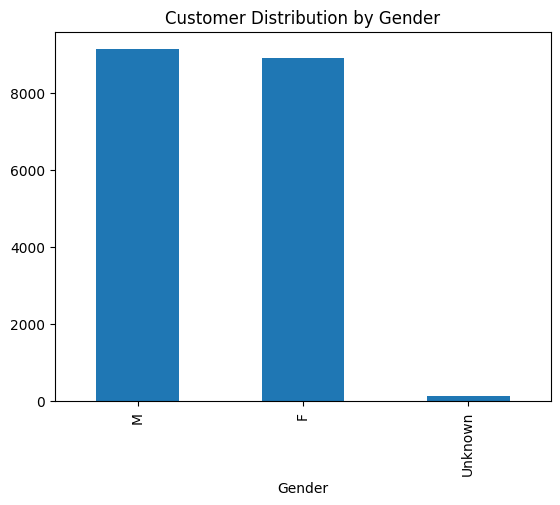

In [31]:
import matplotlib.pyplot as plt

customers_df['Gender'].value_counts().plot(kind='bar')
plt.title('Customer Distribution by Gender')
plt.show()

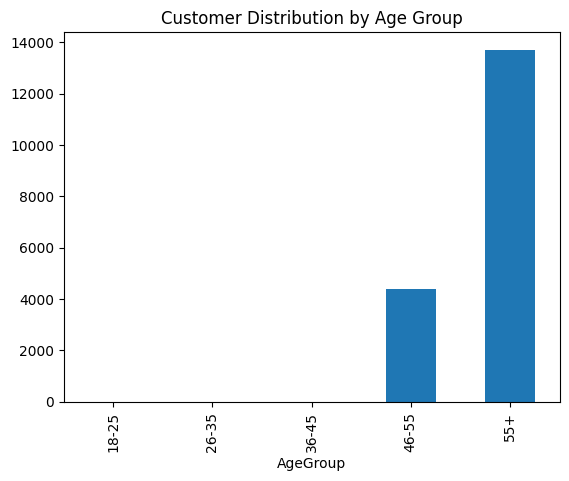

In [35]:
customers_df['AgeGroup'].value_counts().sort_index().plot(kind='bar')
plt.title('Customer Distribution by Age Group')
plt.show()

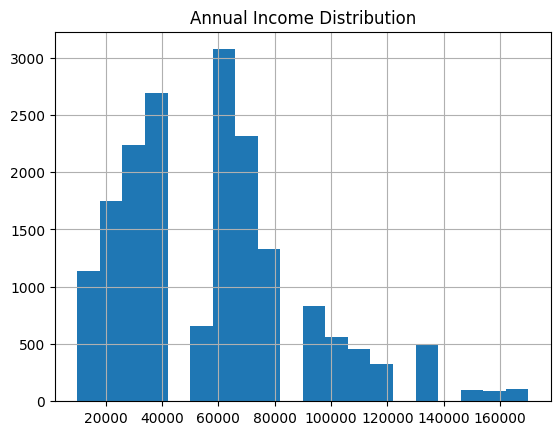

In [36]:
customers_df['AnnualIncome'].hist(bins=20)
plt.title('Annual Income Distribution')
plt.show()

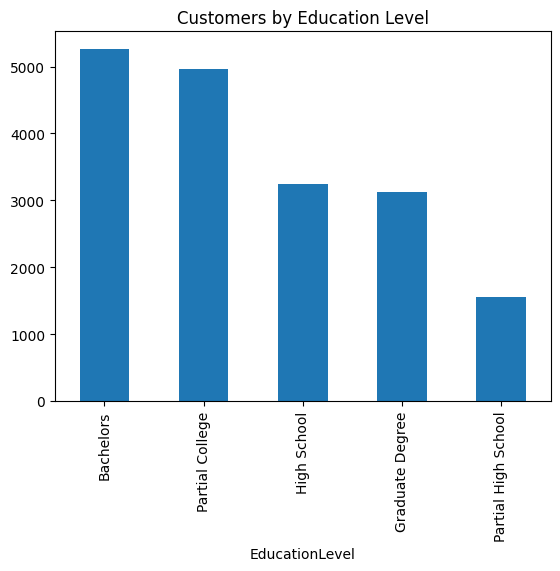

In [37]:
customers_df['EducationLevel'].value_counts().plot(kind='bar')
plt.title('Customers by Education Level')
plt.show()

In [39]:
customers_df.to_csv(
    '/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Customers_Cleaned.csv',
    index=False
)

**Product Categories: Data cleaning & EDA**

> Add blockquote



In [41]:
categories_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Product_Categories.csv')

In [42]:
categories_df.head()

,ProductCategoryKey,CategoryName
0,1,Bikes
1,2,Components
2,3,Clothing
3,4,Accessories


In [43]:
categories_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ProductCategoryKey  4 non-null      int64 
 1   CategoryName        4 non-null      object
dtypes: int64(1), object(1)
memory usage: 196.0+ bytes


In [44]:
categories_df.isnull().sum()

,0
ProductCategoryKey,0
CategoryName,0


In [45]:
categories_df.duplicated().sum()

np.int64(0)

In [46]:
categories_df.to_csv(
    '/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Product_Categories_Cleaned.csv',
    index=False
)

**Product Subcategories: Data Cleaning & EDA**

In [47]:
subcategories_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Product_Subcategories.csv')

In [48]:
subcategories_df.head()

,ProductSubcategoryKey,SubcategoryName,ProductCategoryKey
0,1,Mountain Bikes,1
1,2,Road Bikes,1
2,3,Touring Bikes,1
3,4,Handlebars,2
4,5,Bottom Brackets,2


In [49]:
subcategories_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ProductSubcategoryKey  37 non-null     int64 
 1   SubcategoryName        37 non-null     object
 2   ProductCategoryKey     37 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1020.0+ bytes


In [50]:
subcategories_df.isnull().sum()

,0
ProductSubcategoryKey,0
SubcategoryName,0
ProductCategoryKey,0


In [51]:
subcategories_df.duplicated().sum()

np.int64(0)

In [52]:
subcategories_df.to_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Product_Subcategories_Cleaned.csv', index=False)

**Products: Data Cleaning & EDA**

In [53]:
products_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Products.csv')

In [54]:
products_df.head()

,ProductKey,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice
0,214,31,HL-U509-R,"Sport-100 Helmet, Red",Sport-100,"Universal fit, well-vented, lightweight , snap...",Red,0,0,13.0863,34.9900
1,215,31,HL-U509,"Sport-100 Helmet, Black",Sport-100,"Universal fit, well-vented, lightweight , snap...",Black,0,0,12.0278,33.6442
2,218,23,SO-B909-M,"Mountain Bike Socks, M",Mountain Bike Socks,Combination of natural and synthetic fibers st...,White,M,U,3.3963,9.5000
3,219,23,SO-B909-L,"Mountain Bike Socks, L",Mountain Bike Socks,Combination of natural and synthetic fibers st...,White,L,U,3.3963,9.5000
4,220,31,HL-U509-B,"Sport-100 Helmet, Blue",Sport-100,"Universal fit, well-vented, lightweight , snap...",Blue,0,0,12.0278,33.6442


In [58]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             293 non-null    int64  
 1   ProductSubcategoryKey  293 non-null    int64  
 2   ProductSKU             293 non-null    object 
 3   ProductName            293 non-null    object 
 4   ModelName              293 non-null    object 
 5   ProductDescription     293 non-null    object 
 6   ProductColor           243 non-null    object 
 7   ProductSize            293 non-null    object 
 8   ProductStyle           293 non-null    object 
 9   ProductCost            293 non-null    float64
 10  ProductPrice           293 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 25.3+ KB


In [55]:
products_df.isnull().sum()

,0
ProductKey,0
ProductSubcategoryKey,0
ProductSKU,0
ProductName,0
ModelName,0
ProductDescription,0
ProductColor,50
ProductSize,0
ProductStyle,0
ProductCost,0


In [57]:
products_df.duplicated().sum()

np.int64(0)

In [59]:
products_df['UnitProfit'] = products_df['ProductPrice'] - products_df['ProductCost']

In [60]:
products_df['ProductColor'] = products_df['ProductColor'].fillna('Unknown')

Visualizations

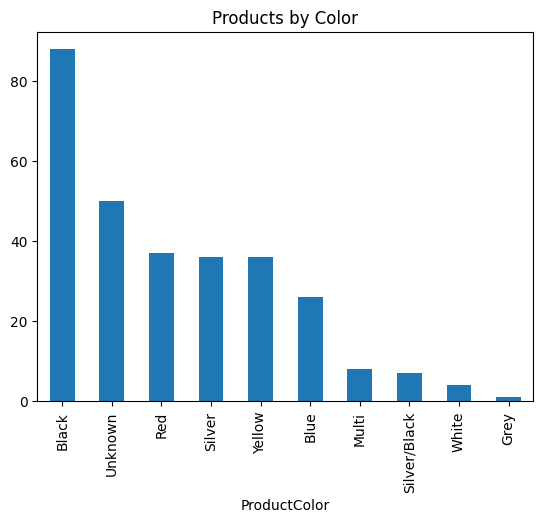

In [61]:
products_df['ProductColor'].value_counts().plot(kind='bar')
plt.title('Products by Color')
plt.show()

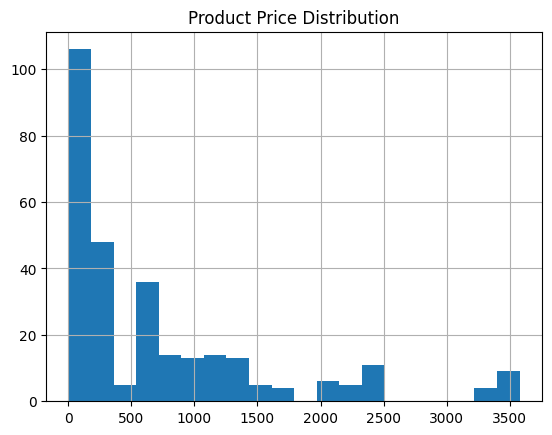

In [62]:
products_df['ProductPrice'].hist(bins=20)
plt.title('Product Price Distribution')
plt.show()

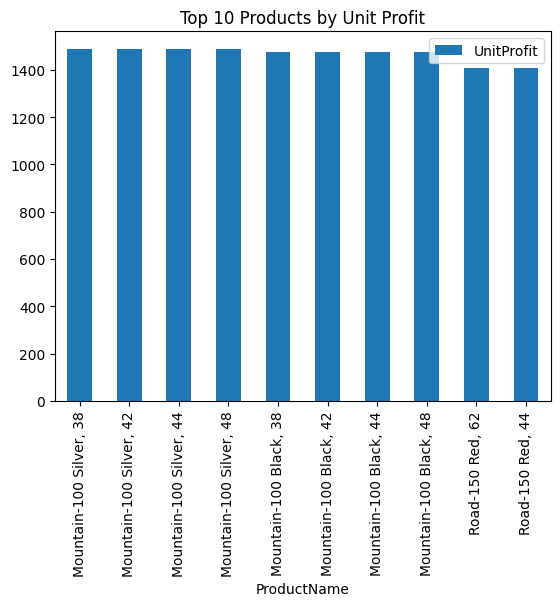

In [63]:
top_profit = products_df.nlargest(10, 'UnitProfit')

top_profit.plot(
    x='ProductName',
    y='UnitProfit',
    kind='bar'
)
plt.title('Top 10 Products by Unit Profit')
plt.show()

In [75]:
products_df.to_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Products_Cleaned.csv', index=False)

**Returns: Data Cleaning & EDA**

In [65]:
returns_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Returns.csv')

In [67]:
returns_df.head()

,ReturnDate,TerritoryKey,ProductKey,ReturnQuantity
0,1/18/2015,9,312,1
1,1/18/2015,10,310,1
2,1/21/2015,8,346,1
3,1/22/2015,4,311,1
4,2/2/2015,6,312,1


In [66]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809 entries, 0 to 1808
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ReturnDate      1809 non-null   object
 1   TerritoryKey    1809 non-null   int64 
 2   ProductKey      1809 non-null   int64 
 3   ReturnQuantity  1809 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 56.7+ KB


In [68]:
returns_df.isnull().sum()

,0
ReturnDate,0
TerritoryKey,0
ProductKey,0
ReturnQuantity,0


In [69]:
returns_df.duplicated().sum()

np.int64(0)

In [70]:
returns_df['ReturnDate'] = pd.to_datetime(returns_df['ReturnDate'])

Visualizations

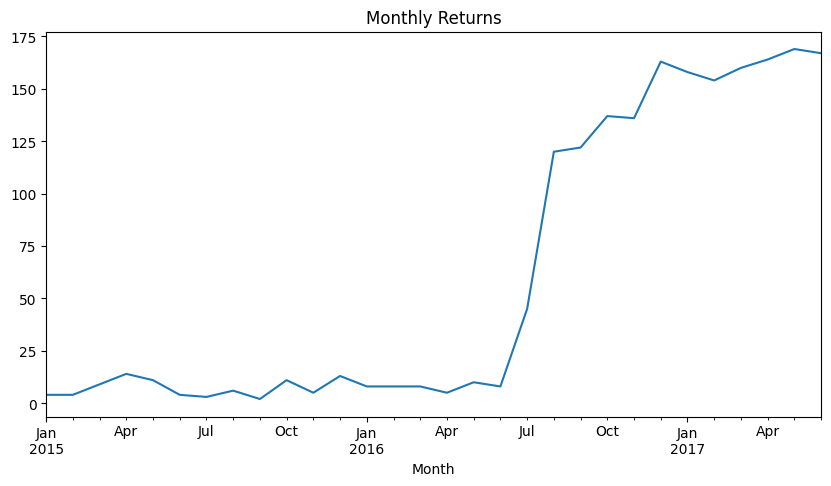

In [72]:
returns_df['Month'] = returns_df['ReturnDate'].dt.to_period('M')

returns_df.groupby('Month')['ReturnQuantity'].sum().plot(figsize=(10,5))
plt.title('Monthly Returns')
plt.show()

In [76]:
returns_df.to_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Returns_Cleaned.csv', index=False)

**Sales: Data Cleaning & EDA**

In [87]:
sales15_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Sales_2015.csv')

sales16_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Sales_2016.csv')

sales17_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Sales_2017.csv')

In [88]:
sales_df = pd.concat(
    [sales15_df, sales16_df, sales17_df],
    ignore_index=True
)

In [89]:
sales_df.head()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
0,1/1/2015,9/21/2001,SO45080,332,14657,1,1,1
1,1/1/2015,12/5/2001,SO45079,312,29255,4,1,1
2,1/1/2015,10/29/2001,SO45082,350,11455,9,1,1
3,1/1/2015,11/16/2001,SO45081,338,26782,6,1,1
4,1/2/2015,12/15/2001,SO45083,312,14947,10,1,1


In [90]:
sales_df.tail()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
56041,6/30/2017,3/22/2004,SO74143,477,28517,10,3,2
56042,6/30/2017,3/15/2004,SO74143,479,28517,10,2,1
56043,6/30/2017,4/8/2004,SO74143,606,28517,10,1,1
56044,6/30/2017,5/15/2004,SO74124,480,21676,7,2,2
56045,6/30/2017,5/4/2004,SO74124,538,21676,7,1,2


In [91]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56046 entries, 0 to 56045
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   OrderDate      56046 non-null  object
 1   StockDate      56046 non-null  object
 2   OrderNumber    56046 non-null  object
 3   ProductKey     56046 non-null  int64 
 4   CustomerKey    56046 non-null  int64 
 5   TerritoryKey   56046 non-null  int64 
 6   OrderLineItem  56046 non-null  int64 
 7   OrderQuantity  56046 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 3.4+ MB


In [92]:
sales15_df.isnull().sum()

,0
OrderDate,0
StockDate,0
OrderNumber,0
ProductKey,0
CustomerKey,0
TerritoryKey,0
OrderLineItem,0
OrderQuantity,0


In [93]:
sales15_df.duplicated().sum()

np.int64(0)

In [94]:
sales_df['OrderDate'] = pd.to_datetime(sales_df['OrderDate'])
sales_df['StockDate'] = pd.to_datetime(sales_df['StockDate'])

In [95]:
sales_df['Year'] = sales_df['OrderDate'].dt.year
sales_df['Month'] = sales_df['OrderDate'].dt.month
sales_df['MonthName'] = sales_df['OrderDate'].dt.month_name()
sales_df['Quarter'] = sales_df['OrderDate'].dt.quarter
sales_df['DayOfWeek'] = sales_df['OrderDate'].dt.day_name()

In [106]:
sales_products = sales_df.merge(
    products_df[
        ['ProductKey',
         'ProductName',
         'ProductPrice',
         'ProductCost',
         'UnitProfit',
         'ProductColor']
    ],
    on='ProductKey',
    how='left'
)

In [109]:
sales_products['Revenue'] = (
    sales_products['OrderQuantity']
    * sales_products['ProductPrice']
)

In [110]:
sales_products['Profit'] = (
    sales_products['OrderQuantity']
    * sales_products['UnitProfit']
)

Visualizations

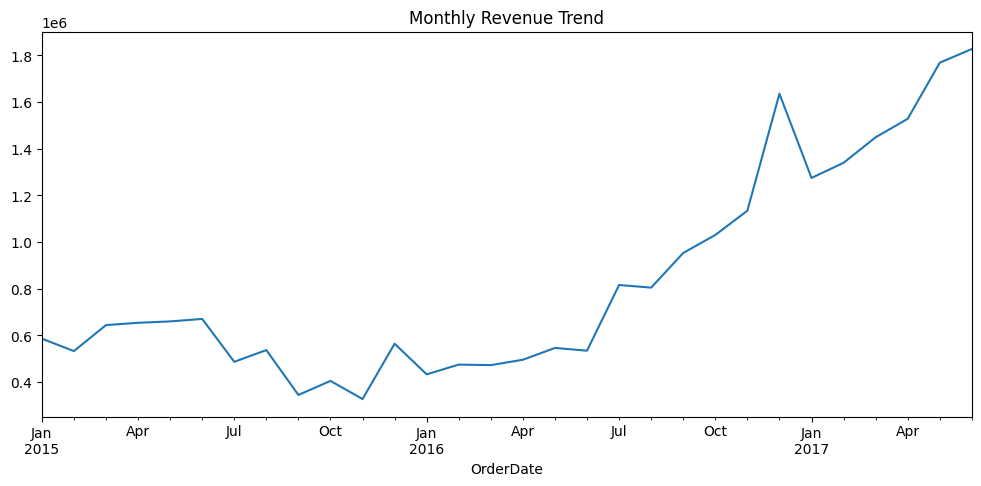

In [100]:
monthly_sales = (
    sales_products
    .groupby(
        sales_products['OrderDate'].dt.to_period('M')
    )['Revenue']
    .sum()
)

monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Revenue Trend')
plt.show()

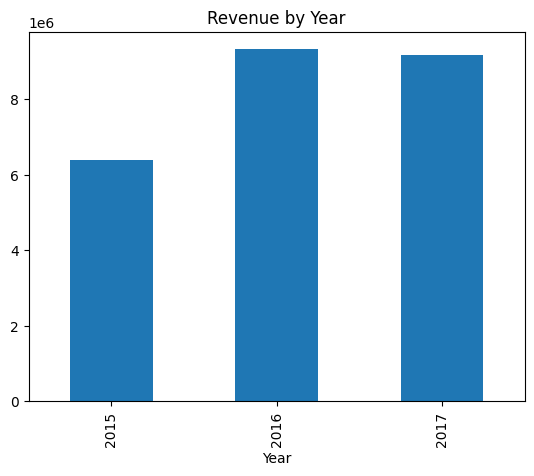

In [101]:
sales_products.groupby('Year')['Revenue'].sum().plot(kind='bar')
plt.title('Revenue by Year')
plt.show()

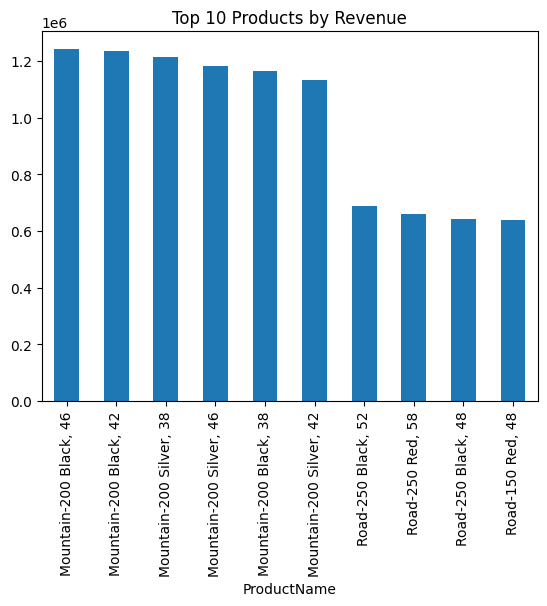

In [102]:
top_products = (
    sales_products.groupby('ProductName')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.show()

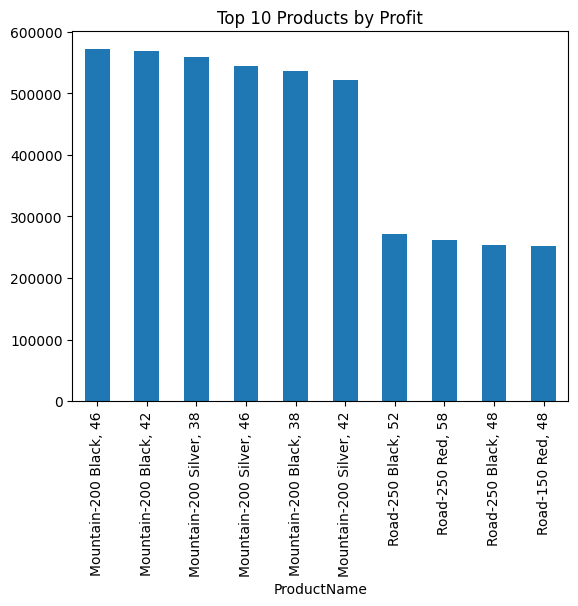

In [103]:
top_profit = (
    sales_products.groupby('ProductName')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit.plot(kind='bar')
plt.title('Top 10 Products by Profit')
plt.show()

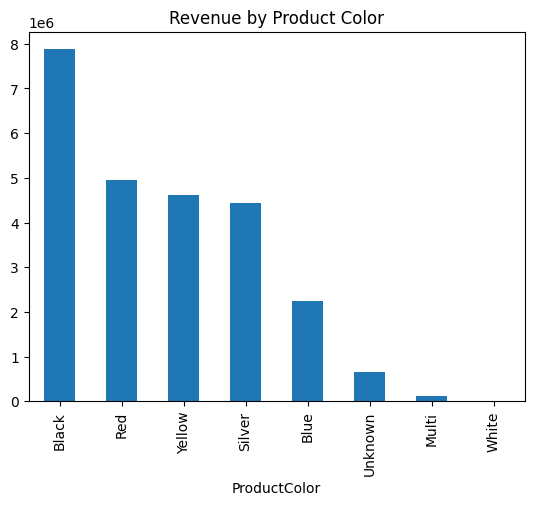

In [111]:
sales_products.groupby('ProductColor')['Revenue']\
              .sum()\
              .sort_values(ascending=False)\
              .plot(kind='bar')

plt.title('Revenue by Product Color')
plt.show()

In [113]:
sales_products.to_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Sales_Cleaned.csv', index=False)

**Territories: Data Cleaning & EDA**

In [114]:
territories_df = pd.read_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Dataset/AdventureWorks_Territories.csv')

In [115]:
territories_df.head()

,SalesTerritoryKey,Region,Country,Continent
0,1,Northwest,United States,North America
1,2,Northeast,United States,North America
2,3,Central,United States,North America
3,4,Southwest,United States,North America
4,5,Southeast,United States,North America


In [116]:
territories_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SalesTerritoryKey  10 non-null     int64 
 1   Region             10 non-null     object
 2   Country            10 non-null     object
 3   Continent          10 non-null     object
dtypes: int64(1), object(3)
memory usage: 452.0+ bytes


In [117]:
territories_df.isnull().sum()

,0
SalesTerritoryKey,0
Region,0
Country,0
Continent,0


In [118]:
territories_df.duplicated().sum()

np.int64(0)

In [119]:
territories_df.to_csv('/content/drive/MyDrive/AdventureWorks Dashboard/Cleaned dataset/Territories_Cleaned.csv', index=False)